In [383]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('science')
plt.rcParams['text.usetex'] = True
#import seaborn; seaborn.set()
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.table import Table
import scipy.stats as stats
import os
import re
from pandas import DataFrame
import pandas as pd
import sys
# 定义颜色
colors = {
    'red': '#E24A33',
    'blue': '#348ABD',
    'green': '#8EBA42',
    'orange': '#FBC15E',
    'purple': '#988ED5',
    'pink': '#FFB5B8',
    'gray': '#777777'
}
plt.rcParams.update({
    'font.size': 12,               # 字体大小
    'font.family': 'sans-serif',    # 字体类型
    'font.sans-serif': ['Arial'],   # 使用 Arial 字体
    'axes.linewidth': 1.5,          # 坐标轴线宽
    'axes.labelsize': 14,           # 坐标轴标签大小
    'axes.titlesize': 14,           # 标题字体大小
    'xtick.labelsize': 12,          # X轴刻度字体大小
    'ytick.labelsize': 12,          # Y轴刻度字体大小
    'xtick.major.size': 5,          # X轴主刻度长度
    'ytick.major.size': 5,          # Y轴主刻度长度
    'xtick.major.width': 1.5,       # X轴主刻度宽度
    'ytick.major.width': 1.5,       # Y轴主刻度宽度
    'legend.fontsize': 12,          # 图例字体大小
    'legend.frameon': False,        # 图例无边框
    'lines.linewidth': 1.5,         # 曲线的默认线宽
    'savefig.dpi': 300,             # 保存图片的分辨率
    'figure.figsize': (7, 5),       # 图形大小 (以英寸为单位)
    'figure.autolayout': False       # 自动调整布局
})

def readfile(tfile): 
    with open(tfile,'r') as f:
        lines=f.readlines()
    return lines

In [384]:
source="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/HHT/20201213_QPOphase/fit_results_bw2"
path0="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/HHT/20201213_QPOphase/fit_results_bw2"
files=os.listdir("%s"%source)

In [385]:
# Models=['gabs','bbodyrad','bwcycl']
# N_Units=[[1,1,1],[1,0],[1,1,1]]
# errs=[2,3,4,6,7,15,17,18]
# Long_index=[1,1,1]

# Models=['gabs','bbodyrad','bwcycl']
# N_Units=[[1,1,1],[1,0],[1,1]]
# errs=[2,3,4,6,7,17,18]
# Long_index=[1,1,1]

# Models=['gabs','bbodyrad','bwcycl']
# N_Units=[[1,1,1],[1,0],[0,0,1,1]]
# errs=[2,3,4,6,7,13,14,17,18]
# Long_index=[1,1,1]

#20201213
# Models=['gabs','bbodyrad','bwcycl']
# N_Units=[[1,1,1],[1,0],[0,0,1,1,1]]
# errs=[2,3,4,6,7,10,11,12,14,15]
# Long_index=[1,1,1]

Models=['gabs','bbodyrad','bwcycl']
N_Units=[[1,1,1],[1,0],[1,1,1]]
errs=[2,3,4,6,7,12,14,15]
Long_index=[1,1,1]

# Models=['gabs','bbodyrad','bwcycl']
# N_Units=[[1,1,1],[1,0],[1,1]]
# errs=[2,3,4,6,7,14,15]
# Long_index=[1,1,1]


In [386]:
def read_fitresults(source,files,Models,N_Unitsi,path0):
    print(files)
    #MJD = read_MJD(files,path0)
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    #print(line_tails)
    j=0
    pars_values=[]
    pars_names=[]
    while j < len(Models):
        pars=re.findall(r"%s.*"%Models[j], all)
        #print(pars)
        l=len(N_Units[j])
        while l > 0:
            p=N_Units[j][-l]
            if Long_index[j] > 1:
                pars_values.append(float(pars[-l-(Long_index[j]-1)*len(N_Units[j+1])].split()[2+p]))
                #print(pars_values)
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
            else:
                pars_values.append(float(pars[-l].split()[2+p]))
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
        j+=1
    par_chi=re.findall(r"Test statistic : Chi-Squared.*", all)
    #print(par_chi[-1].split())
    dofall=re.findall(r"Null hypothesis probability.*", all)
    #print(dofall[-1].split())
    chi2=par_chi[-1].split()[4]
    # print(chi2)
    dof=dofall[-1].split()[6]
    # print(dof)
    red_chi2=float(chi2)/float(dof)
    # print(red_chi2)
    return pars_names, pars_values, red_chi2

In [387]:
def read_errs(source,files,errs,pars_names,pars_values):
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    Err=re.findall(r"Parameter   Credible Interval.*", all)
    l=0
    while l < len(line_tails):
        if Err[0] in line_tails[l]:
            L=l
        else:
            pass
        l+=1
    for e in errs:
        Errs_results=[line_tails[L+1+a].split() for a in range(len(errs))]
    pars_Err_lh=[]
    NE=0
    while NE < len(errs):
        err_low=float(Errs_results[NE][1])
        err_high=float(Errs_results[NE][2])
        pars_Err_lh.append([err_low,err_high])
        NE+=1
    #print(pars_values)
    #get err
    Np=0
    err_LR=[]
    while Np < len(pars_values):
        err_L=pars_values[Np]-pars_Err_lh[Np][0]
        err_R=pars_Err_lh[Np][1]-pars_values[Np]
        err_LR.append([err_L,err_R])
        Np+=1
    err_names_L=["%s_Lerrs"%Name for Name in pars_names]
    err_names_R=["%s_Rerrs"%Name for Name in pars_names]

    err_L=[i[0] for i in err_LR]
    err_R=[i[1] for i in err_LR]

    return err_names_L,err_L,err_names_R,err_R

In [388]:
i=0
red_chi2_all=[]
while i < len(files):
#while i < 1:
    #pars_names, pars_values,red_chi2,dof, MJD, Lum, Lum_errL, Lum_errR=read_fitresults(source,files[i],Models,N_Units,path0)
    pars_names, pars_values, red_chi2=read_fitresults(source,files[i],Models, N_Units,path0)
    red_chi2_all.append(red_chi2)
    #print(red_chi2)
    #print(pars_names)
    fit_names=pars_names
    fit_data=pars_values

    err_names_L, err_L, err_names_R, err_R=read_errs(source,files[i],errs,pars_names,pars_values)
    #print(err_names_L)
    #err_names_L, err_L = err_names_L+['Lum_errL'], err_L+[Lum_errL]
    #err_names_R, err_R = err_names_R+['Lum_errR'], err_R+[Lum_errR]
    
    derr_L=dict(zip(err_names_L,err_L))
    derr_R=dict(zip(err_names_R,err_R))
    if i==0:
        d1 = dict(zip(fit_names,fit_data))
        Para=pd.DataFrame(d1,index=['%s'%files[i]])
        Para_errL=pd.DataFrame(derr_L,index=['%s'%files[i]])
        Para_errR=pd.DataFrame(derr_R,index=['%s'%files[i]])
        i+=1
    else:
        Para.loc['%s'%files[i]]=fit_data
        Para_errL.loc['%s'%files[i]]=err_L
        Para_errR.loc['%s'%files[i]]=err_R
        i+=1
Para_all=pd.concat([Para,Para_errL,Para_errR],axis=1)
#save_data="fit_comptt_final.csv"
#Para_all.to_csv(save_data)

phase_0001.txt
phase_0102.txt
phase_0203.txt
phase_0304.txt
phase_0405.txt
phase_0506.txt
phase_0607.txt
phase_0708.txt
phase_0809.txt
phase_0910.txt


In [389]:
Para_all

,gabs1_LineE,gabs1_Sigma,gabs1_Strength,bbodyrad1_kT,bbodyrad1_norm,bwcycl1_B,bwcycl1_Te,bwcycl1_r0,gabs1_LineE_Lerrs,gabs1_Sigma_Lerrs,...,bwcycl1_Te_Lerrs,bwcycl1_r0_Lerrs,gabs1_LineE_Rerrs,gabs1_Sigma_Rerrs,gabs1_Strength_Rerrs,bbodyrad1_kT_Rerrs,bbodyrad1_norm_Rerrs,bwcycl1_B_Rerrs,bwcycl1_Te_Rerrs,bwcycl1_r0_Rerrs
phase_0001.txt,49.5203,13.3107,27.0771,2.82183,6.42412,6.24121,8.95553,156.263,0.3374,0.0595,...,0.12220,1.852,0.6935,0.5818,2.7992,0.11087,0.26329,0.34189,0.12001,0.374
phase_0102.txt,48.9598,13.2532,23.3679,2.84032,6.63046,6.10119,8.92497,157.973,0.5527,0.3300,...,0.13437,2.098,0.2685,0.7468,1.7369,0.18148,0.62107,0.21017,0.07801,1.097
phase_0203.txt,48.0298,13.4020,20.1308,2.97668,5.92729,5.86346,8.99131,157.696,0.8868,0.4779,...,0.14281,1.208,0.7796,0.6940,1.7236,0.04935,0.80901,0.15968,0.10750,1.450
phase_0304.txt,46.6035,12.5111,15.5020,2.98511,6.66061,5.49484,8.98471,158.687,0.5694,0.4610,...,0.07424,1.072,0.9060,0.7597,1.6188,0.05421,0.52668,0.20141,0.14412,1.010
phase_0405.txt,46.5396,11.6184,12.5982,3.09597,6.59905,5.66030,9.19648,158.372,0.6531,0.4027,...,0.11837,0.598,0.7748,0.5170,0.6457,0.10669,0.90425,0.14330,0.11092,2.087
phase_0506.txt,46.5558,11.7015,13.1786,2.99596,6.97362,5.62698,9.21577,159.619,0.2773,0.5485,...,0.05405,1.342,0.9076,0.6050,1.2114,0.13662,0.57501,0.29255,0.18326,1.126
phase_0607.txt,46.9325,12.4183,17.2645,2.96925,6.62479,5.61072,9.08981,158.739,0.2126,0.4799,...,0.02456,2.681,1.1156,0.6008,1.4651,0.22619,0.60328,0.37377,0.24742,1.184
phase_0708.txt,48.1553,12.6802,20.6539,3.02641,5.92069,5.76557,9.04350,156.875,0.5493,0.3648,...,0.11815,1.370,0.6502,0.4036,1.7314,0.15384,0.46866,0.28998,0.14299,0.680
phase_0809.txt,49.3684,12.2600,22.9112,2.95373,6.87664,6.07968,9.01892,155.677,0.5448,0.2270,...,0.17879,2.257,0.6183,0.6771,2.4455,0.12299,0.37225,0.17499,0.08361,0.699
phase_0910.txt,49.8384,12.7846,26.2279,2.94788,6.40931,6.11620,8.89754,155.244,0.5938,0.2178,...,0.14301,1.318,0.5320,0.7164,3.1427,0.15795,0.63415,0.16236,0.11502,0.767


In [390]:
red_chi2_all=np.array(red_chi2_all)
red_chi2_all

array([0.90071101, 0.89576471, 0.88034314, 0.96643564, 0.90963325,
       0.94428571, 0.9241769 , 1.04602771, 0.94412027, 0.99819599])

In [391]:
# array([1.02469291, 1.04010963, 1.00483516, 0.98260734, 1.03002324,
#        1.00123267, 0.96921947, 1.0378577 , 1.0424181 , 1.03605942])
# array([1.05194988, 1.0372352 , 1.00356753, 1.00218944, 1.05700308,
#        1.01504215, 0.97053036, 1.04151538, 1.05785881, 1.04276827])
# array([1.12392801, 1.05589883, 1.00779251, 1.07849496, 1.1295535 ,
#        1.07886677, 0.97735023, 1.05447348, 1.11148837, 1.12940948])

In [392]:
print(Para_all.columns)
M=len(errs)
print(M)
names=Para_all.columns[:M]
print(names)

Index(['gabs1_LineE', 'gabs1_Sigma', 'gabs1_Strength', 'bbodyrad1_kT',
       'bbodyrad1_norm', 'bwcycl1_B', 'bwcycl1_Te', 'bwcycl1_r0',
       'gabs1_LineE_Lerrs', 'gabs1_Sigma_Lerrs', 'gabs1_Strength_Lerrs',
       'bbodyrad1_kT_Lerrs', 'bbodyrad1_norm_Lerrs', 'bwcycl1_B_Lerrs',
       'bwcycl1_Te_Lerrs', 'bwcycl1_r0_Lerrs', 'gabs1_LineE_Rerrs',
       'gabs1_Sigma_Rerrs', 'gabs1_Strength_Rerrs', 'bbodyrad1_kT_Rerrs',
       'bbodyrad1_norm_Rerrs', 'bwcycl1_B_Rerrs', 'bwcycl1_Te_Rerrs',
       'bwcycl1_r0_Rerrs'],
      dtype='object')
8
Index(['gabs1_LineE', 'gabs1_Sigma', 'gabs1_Strength', 'bbodyrad1_kT',
       'bbodyrad1_norm', 'bwcycl1_B', 'bwcycl1_Te', 'bwcycl1_r0'],
      dtype='object')


In [393]:
# 20201120
# phase_bins=np.array([0.0626961 , 0.12518171, 0.18766732, 0.25015293, 0.31263853,
#         0.37512414, 0.43760975, 0.50009536, 0.56258097, 0.62506658,
#         0.68755218, 0.75003779, 0.8125234 , 0.87500901, 0.93749462,
#         0.99998022, 1.0626961 , 1.12518171, 1.18766732, 1.25015293,
#         1.31263853, 1.37512414, 1.43760975, 1.50009536, 1.56258097,
#         1.62506658, 1.68755218, 1.75003779, 1.8125234 , 1.87500901,
#         1.93749462, 1.99998022])
# profile=np.array([4581.67724052, 4610.92033798, 4860.12465291, 5068.81297456,
#         5393.86217149, 5747.60199984, 5962.29789586, 6057.82552249,
#         6048.60594215, 5912.43659947, 5574.53876438, 5355.41892312,
#         5147.6729164 , 4965.21713747, 4742.3547959 , 4660.97259794,
#         4581.67724052, 4610.92033798, 4860.12465291, 5068.81297456,
#         5393.86217149, 5747.60199984, 5962.29789586, 6057.82552249,
#         6048.60594215, 5912.43659947, 5574.53876438, 5355.41892312,
#         5147.6729164 , 4965.21713747, 4742.3547959 , 4660.97259794])

#20201208
# phase_bins=np.array([0.06252452, 0.1250217 , 0.18751888, 0.25001606, 0.31251324,
#         0.37501042, 0.4375076 , 0.50000478, 0.56250196, 0.62499914,
#         0.68749632, 0.7499935 , 0.81249068, 0.87498786, 0.93748504,
#         0.99998222, 1.06252452, 1.1250217 , 1.18751888, 1.25001606,
#         1.31251324, 1.37501042, 1.4375076 , 1.50000478, 1.56250196,
#         1.62499914, 1.68749632, 1.7499935 , 1.81249068, 1.87498786,
#         1.93748504, 1.99998222])
# profile=np.array([131.64722189, 136.90121243, 149.06787517, 169.11066594,
#         192.93186395, 218.17266589, 238.08678978, 245.07577826,
#         244.13227836, 233.43886042, 211.90095178, 190.21110028,
#         170.45565042, 151.87125414, 138.71959449, 132.0165439 ,
#         131.64722189, 136.90121243, 149.06787517, 169.11066594,
#         192.93186395, 218.17266589, 238.08678978, 245.07577826,
#         244.13227836, 233.43886042, 211.90095178, 190.21110028,
#         170.45565042, 151.87125414, 138.71959449, 132.0165439 ])

#20201213
phase_bins=np.array([0.0625737 , 0.12505472, 0.18753574, 0.25001676, 0.31249777,
        0.37497879, 0.43745981, 0.49994083, 0.56242185, 0.62490287,
        0.68738389, 0.74986491, 0.81234593, 0.87482695, 0.93730797,
        0.99978899, 1.0625737 , 1.12505472, 1.18753574, 1.25001676,
        1.31249777, 1.37497879, 1.43745981, 1.49994083, 1.56242185,
        1.62490287, 1.68738389, 1.74986491, 1.81234593, 1.87482695,
        1.93730797, 1.99978899])
profile=np.array([ 74.11247266,  76.96480527,  84.73580509,  94.67703538,
        109.28895194, 123.81972192, 137.04807947, 142.25929539,
        142.84224237, 137.44075638, 124.01116812, 109.68468293,
         97.98000585,  85.89430308,  77.67582055,  75.43592102,
         74.11247266,  76.96480527,  84.73580509,  94.67703538,
        109.28895194, 123.81972192, 137.04807947, 142.25929539,
        142.84224237, 137.44075638, 124.01116812, 109.68468293,
         97.98000585,  85.89430308,  77.67582055,  75.43592102])



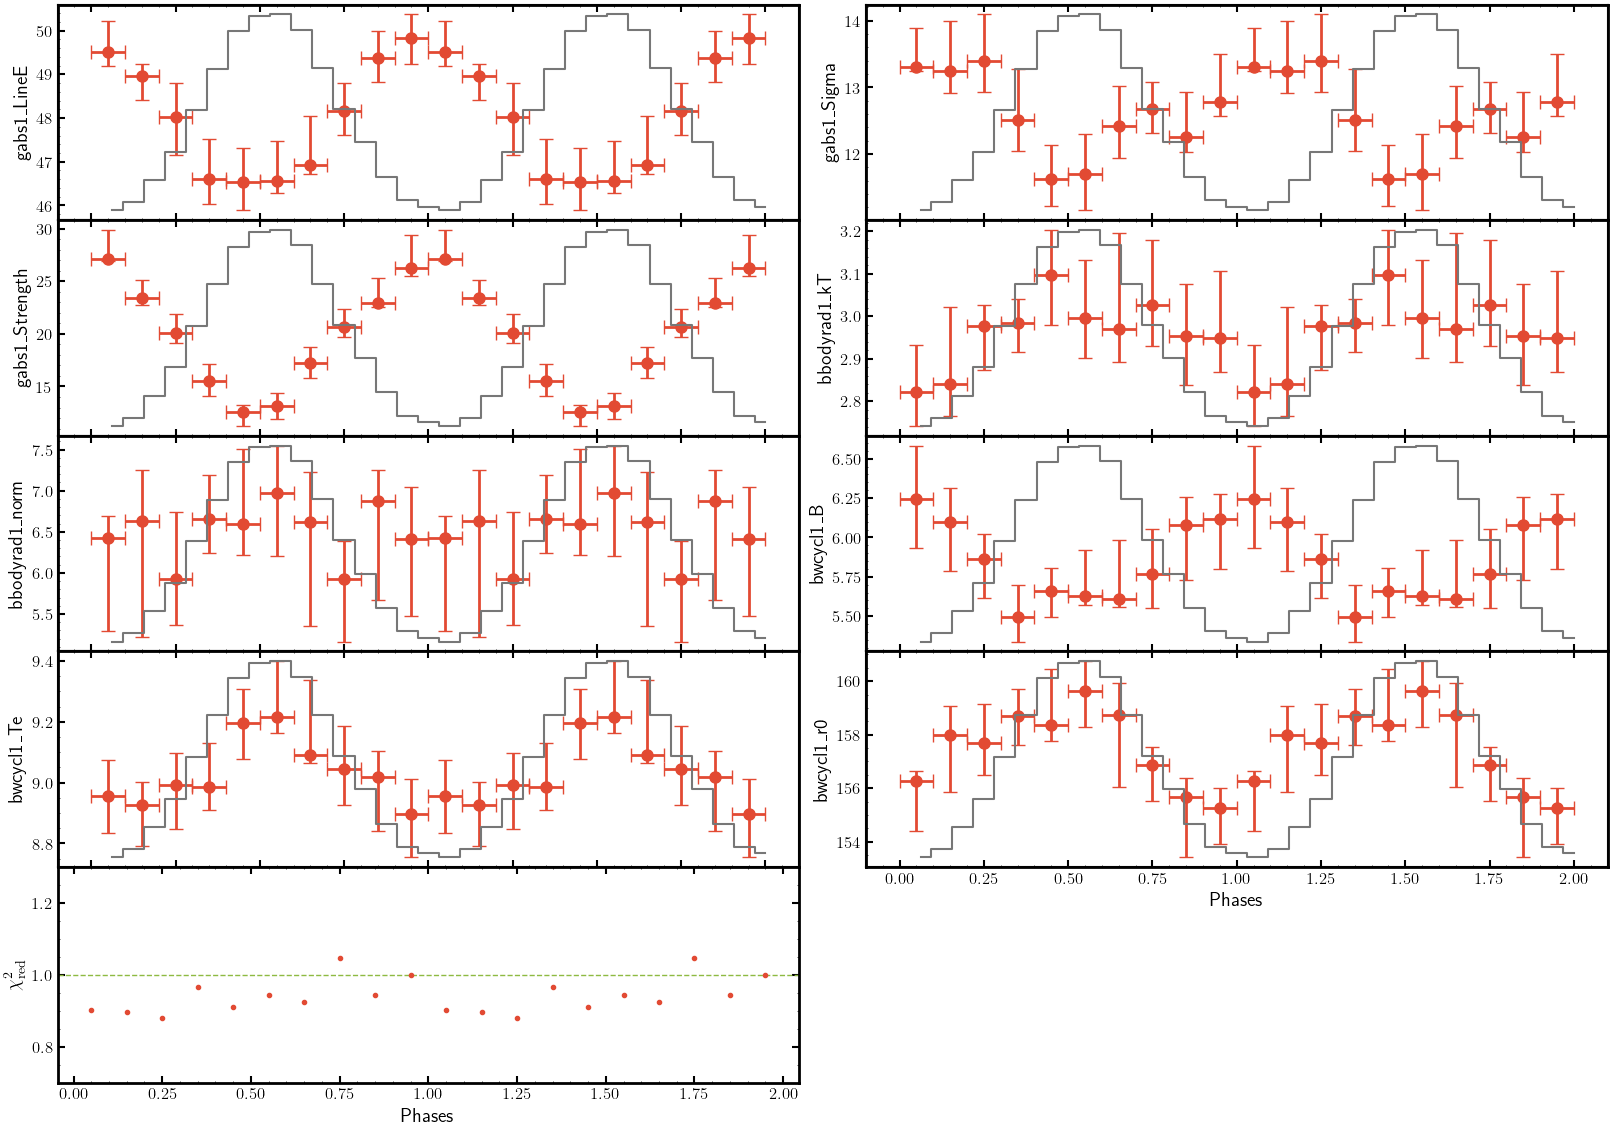

In [394]:
X = np.array([0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95])
x_data=np.hstack([X,X+1])
X_err=np.array([0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05])
x_err=np.hstack([X_err,X_err])
fig, axs = plt.subplots((M)//2+1, 2, figsize=(20, 14))
axs = axs.flatten()
#fig, axs = plt.subplots(M+1,1,figsize=(4, 16))
Ylabels=names
# Ylabels=[r'$E_{\rm cyc1}$ [keV]', r'$\sigma_{\rm cyc1}$ [keV]', r'$S_{\rm cyc1}$ [keV]', 
#          r'$kT_{\rm bb}$ [keV]', r'Norm$_{\rm bb}$',
#          r'$B_{12}$ [G]', r'$kT_{\rm e}$ [keV]', r'$r_{\rm 0}$ [m]']
i=0
while i < len(names):
    name=names[i]
    y1=Para_all['%s'%name].values
    #print(np.mean(y1))
    y1_err=[abs(Para_all['%s_Lerrs'%name].values),abs(Para_all['%s_Rerrs'%name].values)]
    y1=np.hstack([y1,y1])
    #y1=abs(y1)
    y1_err=np.hstack([y1_err,y1_err])
    y1_err=abs(y1_err)
    axs[0+i].errorbar(x_data, y1, xerr=x_err, yerr=y1_err, 
                      fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
    axs2 = axs[0+i].twinx()
    axs2.errorbar(phase_bins, profile/np.mean(profile), 
                  drawstyle='steps-mid',color=colors['gray'],ecolor=colors['gray'])
    #axs2.errorbar(phase_bins2, profile2/np.mean(profile2), drawstyle='steps-mid',color='b',ecolor='b',alpha=0.5)
    axs2.set_yticks([])
    axs[0+i].set_ylabel(Ylabels[i],fontsize=14, fontweight='bold',fontname='Times New Roman')
    axs[i].spines['top'].set_linewidth(2)
    axs[i].spines['right'].set_linewidth(2)
    axs[i].spines['bottom'].set_linewidth(2)
    axs[i].spines['left'].set_linewidth(2)
    i+=1
#plot reduced chi^2 of fitting: 
axs[0+i].errorbar(x_data,np.hstack([red_chi2_all,red_chi2_all]),fmt='.',color=colors['red'],ecolor=colors['red'])
axs[0+i].axhline(y=1, color=colors['green'], linestyle='--',lw=1)
axs[0+i].set_ylim(0.7,1.3)
#axs[0+i].set_xlim(0.0,2.0)
#设置边框
axs[i].spines['top'].set_linewidth(2)
axs[i].spines['right'].set_linewidth(2)
axs[i].spines['bottom'].set_linewidth(2)
axs[i].spines['left'].set_linewidth(2)
# 移除最后一个子图
fig.delaxes(axs[-1])
axs[-3].set_xlabel('Phases',fontsize=14, fontweight='bold',fontname='Times New Roman')
axs[0+i].set_ylim(0.7,1.3)
axs[0+i].set_ylabel(r'$\chi^2_{\rm red}$',fontsize=14, fontweight='bold',fontname='Times New Roman')
axs[0+i].set_xlabel('Phases',fontsize=14, fontweight='bold',fontname='Times New Roman')
plt.subplots_adjust(wspace=0.09,hspace=0)
plt.savefig('20201213_bw.pdf')


In [395]:
for i in names:
    #rms=100*(max(abs(Para_all[i].values))-(min(abs(Para_all[i].values))))/(abs(max(Para_all[i].values))+min(abs(Para_all[i].values)))
    K=np.mean(Para_all[i].values)
    #print('rms:',rms)
    print('mean:',i,K)
    

mean: gabs1_LineE 48.05034
mean: gabs1_Sigma 12.594
mean: gabs1_Strength 19.89121
mean: bbodyrad1_kT 2.9613140000000002
mean: bbodyrad1_norm 6.504658000000001
mean: bwcycl1_B 5.856015
mean: bwcycl1_Te 9.031854
mean: bwcycl1_r0 157.5145


1.3468998011868691

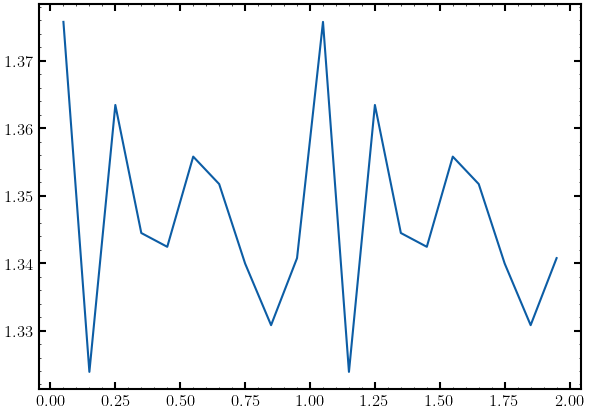

In [162]:
Ratio=Para_all['bwcycl1_B'].values*11.6/Para_all['gabs1_LineE'].values
plt.plot(x_data,np.hstack([Ratio,Ratio]))
np.mean(Ratio)

chi2 (constant model): 69.67
Degrees of freedom (constant model): 19
chi2 (sin model): 0.34
Degrees of freedom (sin model): 16
F value: 1082.40
p value: 1.110223e-16
Sigma: 8.21
P-value: 1.110223e-16


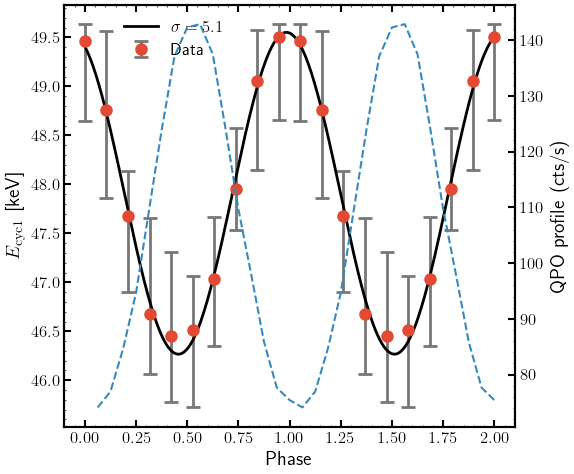

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.stats as stats

# 定义常数函数和正弦函数
def const_func(x, C):
    return C

def sin_func(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 数据
name0 = 'gabs1_LineE'
x = np.linspace(0, 2, 20)
#x = np.linspace(0, 1, 10)

y1 = Para_all['%s' % name0].values
y1_errL = abs(Para_all['%s_Lerrs' % name0].values)
y1_errR = abs(Para_all['%s_Rerrs' % name0].values)
# 示例数据
# y1 = np.random.rand(20)  # 请用实际数据替换
# y1_errL = np.random.rand(20) * 0.1  # 请用实际数据替换
# y1_errR = np.random.rand(20) * 0.1  # 请用实际数据替换

y1 = np.hstack([y1, y1])
y1_errL = np.hstack([y1_errL, y1_errL])
y1_errR = np.hstack([y1_errR, y1_errR])

y_edge1_MaxTau = y1
y_err_lower_edge1_MaxTau = y1_errL
y_err_upper_edge1_MaxTau = y1_errR
y_err_edge1_MaxTau = (y_err_lower_edge1_MaxTau + y_err_upper_edge1_MaxTau) / 2

# 常数函数拟合
params_const, _ = curve_fit(const_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True)
y_fit_const = const_func(x, *params_const)
chi2_const = np.sum(((y_edge1_MaxTau - y_fit_const) / y_err_edge1_MaxTau) ** 2)
dof_const = len(y_edge1_MaxTau) - len(params_const)

# 正弦函数拟合
params_sin, params_covariance_sin = curve_fit(sin_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True, 
                                              p0=[40, 2*np.pi, 0, 0.4])
y_fit_sin = sin_func(x, *params_sin)
chi2_sin = np.sum(((y_edge1_MaxTau - y_fit_sin) / y_err_edge1_MaxTau) ** 2)
dof_sin = len(y_edge1_MaxTau) - len(params_sin)

# 计算 F 值
F_value = ((chi2_const - chi2_sin) / (dof_const - dof_sin)) / (chi2_sin / dof_sin)

# 计算 p 值
p_value = 1 - stats.f.cdf(F_value, dof_const - dof_sin, dof_sin)

# 输出结果
print(f"chi2 (constant model): {chi2_const:.2f}")
print(f"Degrees of freedom (constant model): {dof_const}")
print(f"chi2 (sin model): {chi2_sin:.2f}")
print(f"Degrees of freedom (sin model): {dof_sin}")
print(f"F value: {F_value:.2f}")
print(f"p value: {p_value:.6e}")  # 使用科学计数法显示非常小的p值

# 计算 Z 分数（标准差数）
z_score = stats.norm.ppf(1 - p_value)  # 使用 1 - p_value 计算Z分数

# 使用更多的点使得拟合线条更平滑
x_smooth = np.linspace(0, 2, 400)
#x_smooth = np.linspace(0, 1, 400)
y_fit_smooth_sin = sin_func(x_smooth, *params_sin)

# 绘制拟合结果图像
fig, ax = plt.subplots(figsize=(6, 5))

# 绘制数据点和误差棒
ax.errorbar(x, y_edge1_MaxTau, yerr=[y_err_lower_edge1_MaxTau, y_err_upper_edge1_MaxTau], fmt='o', label='Data', color=colors['red'], ecolor=colors['gray'], elinewidth=2, capsize=5, capthick=2, markersize=8)
ax2 = ax.twinx()
# ax2.errorbar(phase_bins, profile/np.mean(profile), 
#                   drawstyle='steps-mid',color=colors['gray'],ecolor=colors['gray'])
ax2.errorbar(phase_bins, profile, 
                  fmt='--',color=colors['blue'],ecolor=colors['blue'],label='QPO profile')
ax2.set_ylabel('QPO profile (cts/s)')
# ax2 = ax.twinx()
# ax2.errorbar(phase_bins, profile/np.mean(profile), 
#                   drawstyle='steps-mid',color=colors['gray'],ecolor=colors['gray'])
#     #axs2.errorbar(phase_bins2, profile2/np.mean(profile2), drawstyle='steps-mid',color='b',ecolor='b',alpha=0.5)
# 添加 sigma 值的文本
#textstr = r'$\sigma=%.2f$' % (z_score, )
myvalue=5.1
textstr = r'$\sigma=%.1f$' % (myvalue, )
# 绘制平滑后的拟合正弦波
ax.plot(x_smooth, y_fit_smooth_sin, label=textstr, color='black', linewidth=2)

# 设置文本框的外观
#props = dict(boxstyle='round', facecolor='white', alpha=0.5)
#ax.text(0.25, 0.95, textstr, transform=ax.transAxes, fontsize=14, verticalalignment='top')

# 设置标签和标题
# ax.set_xlabel('Phase', fontsize=14, fontweight='bold',fontname='Times New Roman')
# ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]', fontsize=14, fontweight='bold',fontname='Times New Roman')
ax.set_xlabel('Phase')
ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]')
# 显示图例
ax.legend(loc='upper left',bbox_to_anchor=(0.1, 1))

# 去掉网格
ax.grid(False)

# 调整刻度和刻度标签
# ax.spines['top'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
#ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('Date: 2020-11-20', fontsize=14, fontweight='bold',fontname='Times New Roman')
#ax.set_title('Date: 2020-11-20')
# 美化图形外观
fig.tight_layout()
# 保存图像为PDF（如需要）
fig.savefig("20201213_bw_sigma.pdf")
print(f"Sigma: {z_score:.2f}")
print(f"P-value: {p_value:.6e}")



In [52]:
print(np.mean(Para_all['%s' % name0].values)),print(np.max(Para_all['%s' % name0].values)),print(np.min(Para_all['%s' % name0].values))

43.50147
47.0869
39.6875


(None, None, None)

In [53]:
print([np.array(Para_all['%s' % name0].values)])
print([Para_all['%s_Lerrs' % name0].values,Para_all['%s_Rerrs' % name0].values])

[array([46.7069, 45.4768, 42.5435, 40.4825, 40.1051, 39.6875, 41.9164,
       44.3874, 46.6217, 47.0869])]
[array([0.39  , 0.7508, 0.5476, 0.6376, 1.3202, 0.4741, 0.7096, 0.6309,
       0.8281, 0.4714]), array([0.4239, 0.8707, 0.7481, 0.7042, 0.7574, 0.5779, 0.8007, 0.4619,
       0.3139, 0.3005])]


chi2 (constant model): 17.67
Degrees of freedom (constant model): 19
chi2 (sin model): 3.44
Degrees of freedom (sin model): 16
F value: 22.04
p value: 6.307430e-06
Sigma: 4.37
P-value: 6.307430e-06


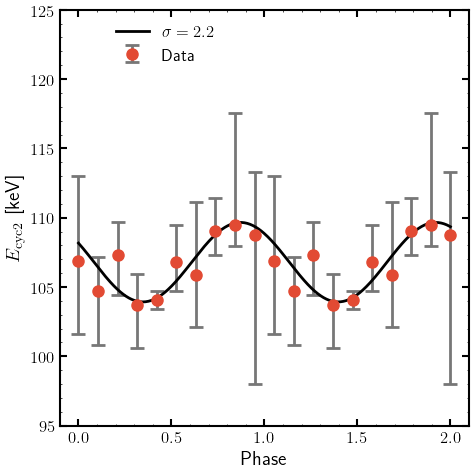

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.stats as stats

# 定义常数函数和正弦函数
def const_func(x, C):
    return C

def sin_func(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 数据
name0 = 'gabs2_Sigma'
x = np.linspace(0, 2, 20)
#x = np.linspace(0, 1, 10)
# 这里需要使用实际数据集 Para_all，如果没有数据，可以用随机数据代替
y1 = Para_all['%s' % name0].values
y1_errL = abs(Para_all['%s_Lerrs' % name0].values)
y1_errR = abs(Para_all['%s_Rerrs' % name0].values)
# 示例数据
# y1 = np.random.rand(20)  # 请用实际数据替换
# y1_errL = np.random.rand(20) * 0.1  # 请用实际数据替换
# y1_errR = np.random.rand(20) * 0.1  # 请用实际数据替换

y1 = np.hstack([y1, y1])
y1_errL = np.hstack([y1_errL, y1_errL])
y1_errR = np.hstack([y1_errR, y1_errR])

y_edge1_MaxTau = y1
y_err_lower_edge1_MaxTau = y1_errL
y_err_upper_edge1_MaxTau = y1_errR
y_err_edge1_MaxTau = (y_err_lower_edge1_MaxTau + y_err_upper_edge1_MaxTau) / 2

# 常数函数拟合
params_const, _ = curve_fit(const_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True)
y_fit_const = const_func(x, *params_const)
chi2_const = np.sum(((y_edge1_MaxTau - y_fit_const) / y_err_edge1_MaxTau) ** 2)
dof_const = len(y_edge1_MaxTau) - len(params_const)

# 正弦函数拟合
params_sin, params_covariance_sin = curve_fit(sin_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True, 
                                              p0=[40, 2*np.pi, 0, 0.4])
y_fit_sin = sin_func(x, *params_sin)
chi2_sin = np.sum(((y_edge1_MaxTau - y_fit_sin) / y_err_edge1_MaxTau) ** 2)
dof_sin = len(y_edge1_MaxTau) - len(params_sin)

# 计算 F 值
F_value = ((chi2_const - chi2_sin) / (dof_const - dof_sin)) / (chi2_sin / dof_sin)

# 计算 p 值
p_value = 1 - stats.f.cdf(F_value, dof_const - dof_sin, dof_sin)

# 输出结果
print(f"chi2 (constant model): {chi2_const:.2f}")
print(f"Degrees of freedom (constant model): {dof_const}")
print(f"chi2 (sin model): {chi2_sin:.2f}")
print(f"Degrees of freedom (sin model): {dof_sin}")
print(f"F value: {F_value:.2f}")
print(f"p value: {p_value:.6e}")  # 使用科学计数法显示非常小的p值

# 计算 Z 分数（标准差数）
z_score = stats.norm.ppf(1 - p_value)  # 使用 1 - p_value 计算Z分数

# 使用更多的点使得拟合线条更平滑
x_smooth = np.linspace(0, 2, 400)
#x_smooth = np.linspace(0, 1, 400)
y_fit_smooth_sin = sin_func(x_smooth, *params_sin)

# 绘制拟合结果图像
fig, ax = plt.subplots(figsize=(5, 5))

# 绘制数据点和误差棒
ax.errorbar(x, y_edge1_MaxTau, yerr=[y_err_lower_edge1_MaxTau, y_err_upper_edge1_MaxTau], fmt='o', label='Data', color=colors['red'], ecolor=colors['gray'], elinewidth=2, capsize=5, capthick=2, markersize=8)

# 添加 sigma 值的文本
#textstr = r'$\sigma=%.2f$' % (z_score, )
myvalue=2.2
textstr = r'$\sigma=%.1f$' % (myvalue, )
# 绘制平滑后的拟合正弦波
ax.plot(x_smooth, y_fit_smooth_sin, label=textstr, color='black', linewidth=2)

# 设置文本框的外观
#props = dict(boxstyle='round', facecolor='white', alpha=0.5)
#ax.text(0.25, 0.95, textstr, transform=ax.transAxes, fontsize=14, verticalalignment='top')

# 设置标签和标题
# ax.set_xlabel('Phase', fontsize=14, fontweight='bold',fontname='Times New Roman')
# ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]', fontsize=14, fontweight='bold',fontname='Times New Roman')
ax.set_xlabel('Phase')
ax.set_ylabel(r'$E_{\rm cyc2}$ [keV]')
# 显示图例
ax.legend(loc='upper left',bbox_to_anchor=(0.1, 1))
ax.set_ylim(95,125)
# 去掉网格
ax.grid(False)

# 调整刻度和刻度标签
# ax.spines['top'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
#ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('Date: 2020-11-20', fontsize=14, fontweight='bold',fontname='Times New Roman')
#ax.set_title('Date: 2020-11-20')
# 美化图形外观
fig.tight_layout()
# 保存图像为PDF（如需要）
fig.savefig("20201120_fdcut_sigma2.pdf")
print(f"Sigma: {z_score:.2f}")
print(f"P-value: {p_value:.6e}")